2026-05-20 14:09:31 [info     ] Discovering aer plugins...    
2026-05-20 14:09:34 [debug    ] Loaded searcher: search_planetary_computer
2026-05-20 14:09:34 [debug    ] Loaded searcher: search_earthaccess
2026-05-20 14:09:34 [debug    ] Loaded extractor: extract_satpy
2026-05-20 14:09:34 [debug    ] Loaded extractor: extract_odc_stac
2026-05-20 14:09:34 [debug    ] Loaded extractor: extract_aws_goes
2026-05-20 14:09:34 [debug    ] Loaded searcher: search_aws_goes
Searching...
2026-05-20 14:09:34 [info     ] search_called                  profiles=['s2_rgb']
2026-05-20 14:09:35 [debug    ] search_completed               count=12 plugin=search_planetary_computer profiles=['s2_rgb']
        collection              start_time                end_time
0   sentinel-2-l2a 2024-04-09 14:27:11.024 2024-04-09 14:27:11.024
1   sentinel-2-l2a 2024-04-09 14:27:11.024 2024-04-09 14:27:11.024
2   sentinel-2-l2a 2024-04-09 14:27:11.024 2024-04-09 14:27:11.024
3   sentinel-2-l2a 2024-04-09 14:27:11.024

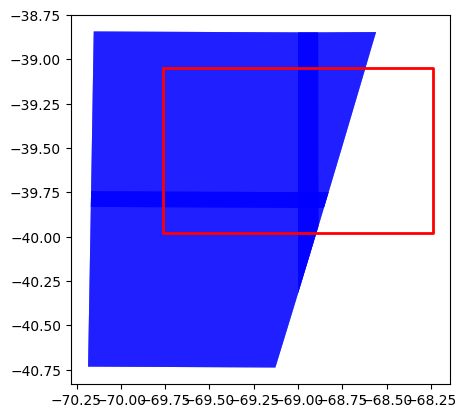

In [1]:

from datetime import datetime, timezone
from pathlib import Path

import geopandas as gpd
from aer.client import AerClient
from aer.interfaces import AerProfile, GridConfig

# --- Configuration ---

# Use a historical date known to have Sentinel-2 coverage over AOI.
DATE_START = datetime(2024, 4, 8, 14, 0, tzinfo=timezone.utc)
DATE_END = datetime(2024, 4, 9, 15, 0, tzinfo=timezone.utc)
URI = "/tmp/02_sentinel2_msi_extraction"

# Shared AOI — path relative to this script so it works regardless of CWD
data_dir = Path("/root/repos/aer/examples/data")

geojson_path = data_dir / "chocon.geojson"
gdf = gpd.read_file(geojson_path)
aoi = gdf.geometry.iloc[0]

# %%
# Load profiles and grid config from YAML.
all_profiles = {p.name: p for p in AerProfile.from_yaml(data_dir / "profiles.yaml")}
grid = GridConfig.from_yaml(data_dir / "grid_config.yaml")

# Select the profile to use for extraction.
profiles = [all_profiles["s2_rgb"]]

# --- Client Setup ---
client = AerClient()
print("Searching...", flush=True)
results = client.search(
    profiles=profiles,
    start_datetime=DATE_START,
    end_datetime=DATE_END,
    intersects=aoi,
)
print(results[["collection", "start_time", "end_time"]].to_string())
# %%
# plt union_all and aoi as overlay
import matplotlib.pyplot as plt

fig, ax = plt.subplots()
results.geometry.plot(ax=ax, color="blue", alpha=0.5)
xs, ys = aoi.exterior.xy
ax.plot(xs, ys, color="red", linewidth=2, label="AOI boundary")
# %%
# Keep a single representative asset to keep the example fast
# results = results.drop_duplicates(subset=["collection"])
print(f"Kept {len(results)} representative result(s)")

# %%
# Prepare extraction tasks using the same profiles.
# cells_per_chunk=1 keeps the example fast and lightweight.

tasks = client.prepare_for_extraction(
    results,  # type: ignore[arg-type]
    grid_config=grid,
    target_aoi=aoi,
    uri=URI,
    profiles=profiles,
    cells_per_chunk=20,
)

print(f"Prepared {len(tasks)} extraction tasks", flush=True)

# For the smoke test we keep only the first task to stay within memory limits.
# In production you would extract all tasks.
# tasks = tasks[:1]
print(f"Extracting {len(tasks)} task(s)...", flush=True)

In [2]:
import pandas as pd
import planetary_computer
import pystac

extraction_task = tasks[0]
assets = extraction_task.assets
grid_cells = extraction_task.grid_cells
uri = extraction_task.uri

# Collect ALL unique STAC items from the task assets so that
# odc.stac.load can mosaic multiple overlapping tiles together.
stac_items: list[pystac.Item] = []
seen_ids: set[str] = set()
for _, row in assets.iterrows():
    stac_item_dict = row.get("stac_item")
    if stac_item_dict and not pd.isna(stac_item_dict):
        
        item = pystac.Item.from_dict(stac_item_dict)
        if item.id not in seen_ids:
            item = planetary_computer.sign(item)
            stac_items.append(item)
            seen_ids.add(item.id)

# %%
grid_cell = grid_cells[0]
target_geobox = grid_cell.area_def(
    10,
)

In [3]:
import time

import dask.distributed
import dask.utils
import numpy as np
import odc
import planetary_computer as pc
import xarray as xr
from IPython.display import display
from odc.stac import configure_rio, stac_load
from pystac_client import Client

# client = dask.distributed.Client()
# configure_rio(cloud_defaults=True, client=client)
# display(client)




In [5]:
stac_items[0]

<Item id=S2A_MSIL2A_20240409T142711_R053_T19HES_20240410T155932>

In [10]:
start_time = time.time()
ds = stac_load(

    stac_items, bands=["red"],
    # geobox=target_geobox,
    
    chunks={"x":2024, "y":2024}
)

print(f"Loaded data in {time.time() - start_time:.2f} seconds")

Loaded data in 0.04 seconds


In [19]:
start_time = time.time()

ds_geo = odc.stac.load(


    stac_items, bands=["red", "blue", "green"],
    geobox=target_geobox,
    
    chunks={"x":2024, "y":2024}
)

print(f"Loaded data in {time.time() - start_time:.2f} seconds")

Loaded data in 0.02 seconds


In [21]:
ds_geo.compute()

<xarray.Dataset> Size: 300MB
Dimensions:      (y: 5000, x: 5000, time: 1)
Coordinates:
  * y            (y) float64 40kB 5.578e+06 5.578e+06 ... 5.528e+06 5.528e+06
  * x            (x) float64 40kB 4.052e+05 4.052e+05 ... 4.552e+05 4.552e+05
  * time         (time) datetime64[us] 8B 2024-04-09T14:27:11.024000
    spatial_ref  int32 4B 32719
Data variables:
    red          (time, y, x) float32 100MB 2.36e+03 2.404e+03 ... 2.588e+03
    blue         (time, y, x) float32 100MB 1.67e+03 1.678e+03 ... 1.72e+03
    green        (time, y, x) float32 100MB 1.922e+03 1.977e+03 ... 2.042e+03

Loaded data in 3.66 seconds


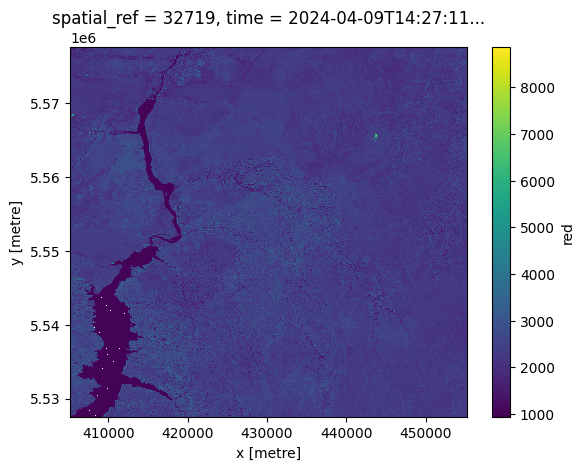

In [ ]:

start_time = time.time()
ds_geo[["red", "blue", "green"]].plot()
print(f"Loaded data in {time.time() - start_time:.2f} seconds")

Loaded data in 3.47 seconds


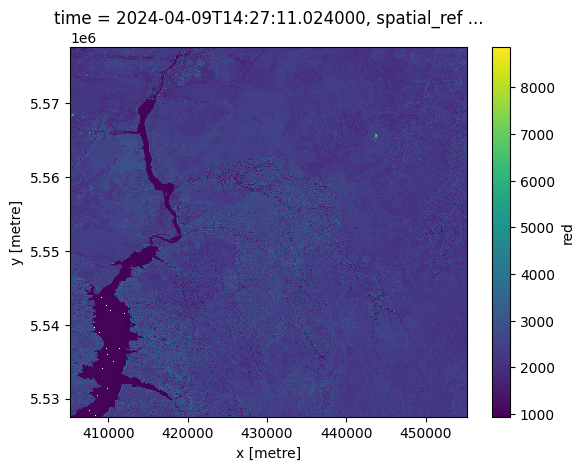

In [17]:


start_time = time.time()
ds.odc.reproject(target_geobox)["red"].plot()

print(f"Loaded data in {time.time() - start_time:.2f} seconds")